In [29]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm

NUMBER_OF_SQUARES = 20
NUMBER_OF_GAMES = int(1e4)
START_POS_ALICE = 1
START_POS_BOB = NUMBER_OF_SQUARES - 2
NUMBER_OF_HARMONICS = 5

np.set_printoptions(formatter={'float': '{: 0.2f}'.format}, linewidth=100)

In [30]:
# Softmax to perform Boltzmann exploration
def softmax(vector, temperature):
  exp_vector = np.exp(vector / temperature)
  return exp_vector / np.sum(exp_vector)

class Walker():
  def __init__(self, name, start_position, world_dimension, use_brain, learn, learning_rate=0.5, discount_factor=1, softmax_temperature=5):
    self.name = name
    self.start_position = start_position
    self.position = start_position

    self.memory = {
        'my_previous_position': None,
        'my_previous_move': None,
        'other_walker_previous_position': None
    }

    self.world_dimension = world_dimension

    # Initialization as random walker
    self.q_table = np.ones((world_dimension, world_dimension, 3)) / 3

    self.learning_rate = learning_rate
    self.discount_factor = discount_factor

    self.softmax_temperature = softmax_temperature

    self.use_brain = use_brain
    self.learn = learn

  def reset(self):
    self.position = self.start_position
    self.memory = {
        'my_previous_position': None,
        'my_previous_move': None,
        'other_walker_previous_position': None
    }

  def update_memory(self, my_position, other_position, my_move):
    self.memory['my_previous_position'] = my_position
    self.memory['my_previous_move'] = my_move
    self.memory['other_walker_previous_position'] = other_position

  def get_policy_tensor(self):
    probability_tensor = np.zeros((self.world_dimension, self.world_dimension, 3))
    for i in range(self.world_dimension):
      for j in range(self.world_dimension):
        probability_tensor[i, j] = softmax(self.q_table[i, j], self.softmax_temperature)
    return probability_tensor

  def choose_move(self, other_walker_position):
    if self.use_brain:
      # Policy
      probabilities = softmax(self.q_table[self.position, other_walker_position], self.softmax_temperature)
      move = np.random.choice([-1, 0, 1], p=probabilities)
    else:
      move = np.random.choice([-1, 0, 1])
    return move

  def check_if_move_is_possible(self, move):
    # Check if we end up under 0
    if self.position + move < 0:
      return False
    # Check if we end up over the world dimension
    elif self.position + move >= self.world_dimension:
      return False
    else:
      return True

  def move(self, other_position):
    move = self.choose_move(other_position)
    self.update_memory(self.position, other_position, move)
    if self.check_if_move_is_possible(move):
      self.position += move

  def update_brain(self, reward, other_position):
    if self.learn:
      old_q_value = self.q_table[self.memory['my_previous_position'], self.memory['other_walker_previous_position'], self.memory['my_previous_move'] + 1]
      new_q_value = reward + self.discount_factor * np.max(self.q_table[self.position, other_position])
      self.q_table[self.memory['my_previous_position'], self.memory['other_walker_previous_position'], self.memory['my_previous_move'] + 1] = \
        (1-self.learning_rate) * old_q_value + self.learning_rate * new_q_value


In [31]:
def check_same_position(walker_1, walker_2):
  if walker_1.position == walker_2.position:
    return True
  else:
    return False

def check_compenetration(walker_1, walker_2):
  if walker_1.memory['my_previous_position'] == walker_2.position and walker_2.memory['my_previous_position'] == walker_1.position:
    return True
  else:
    return False

def check_end_game(walker_1, walker_2):
  end_game = False
  compenetration = False
  if check_same_position(walker_1, walker_2):
    end_game = True
  elif check_compenetration(walker_1, walker_2):
    # Coin toss to choose the final position of the two walkers
    if np.random.rand() < 0.5:
      walker_1.position = walker_2.position
    else:
      walker_2.position = walker_1.position
    end_game = True
    compenetration = True
  else:
    end_game = False

  return end_game, compenetration


def play_one_game(walker_1, walker_2, world_dimension, calculate_reward, learning=True):
  # Reset the walkers
  walker_1.reset()
  walker_2.reset()
  moves = 0
  while True:
    walker_1.move(walker_2.position)
    walker_2.move(walker_1.position)
    moves += 1

    end_game, compenetration = check_end_game(walker_1, walker_2)

    if end_game:

      if walker_1.position != walker_2.position:
        raise Exception('The walkers are not in the same position at the end of the game')
      else:
        meeting_square = walker_1.position

      walker_1_reward, walker_2_reward = calculate_reward(
          meeting_square,
          world_dimension,
        )
      if learning:
        walker_1.update_brain(walker_1_reward, walker_2.position)
        walker_2.update_brain(walker_2_reward, walker_1.position)
      break
    else:
      if learning:
        walker_1.update_brain(0, walker_2.position)
        walker_2.update_brain(0, walker_1.position)

  return walker_1_reward, walker_2_reward, moves, meeting_square, compenetration

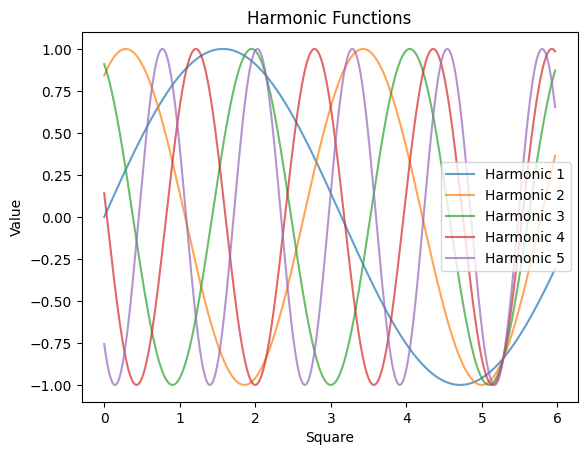

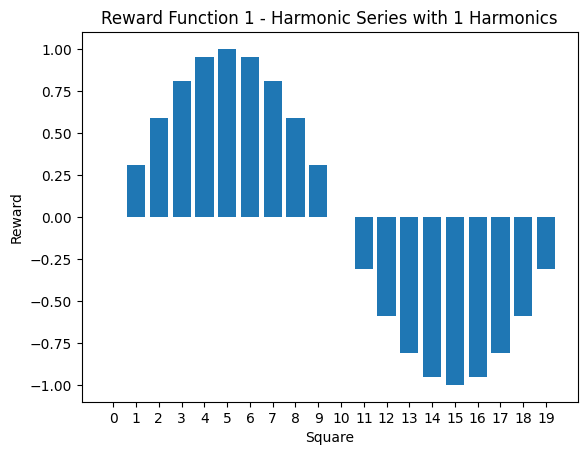

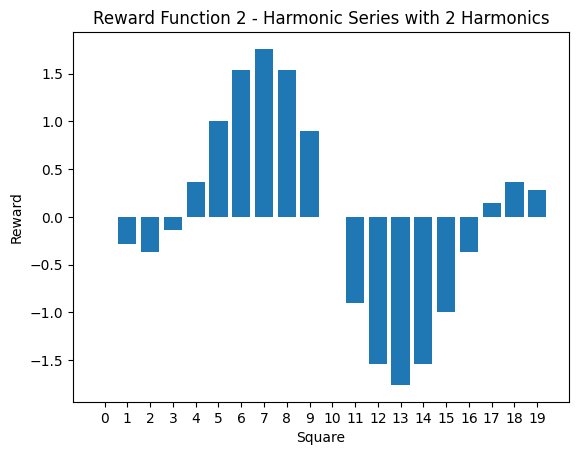

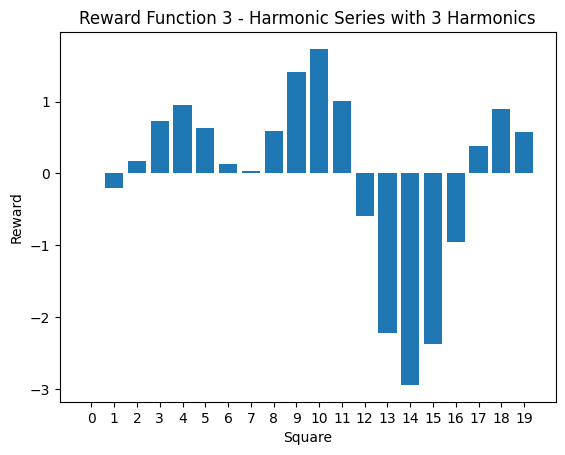

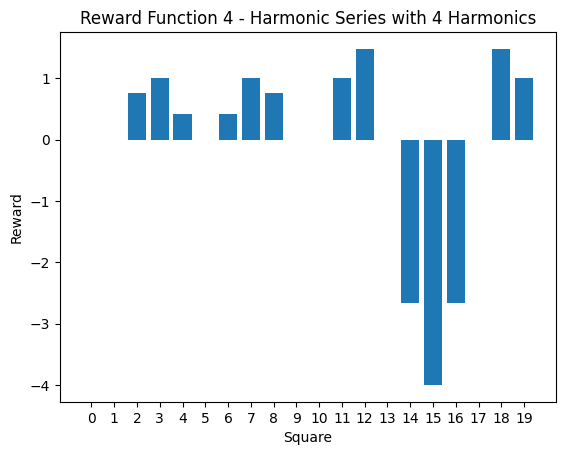

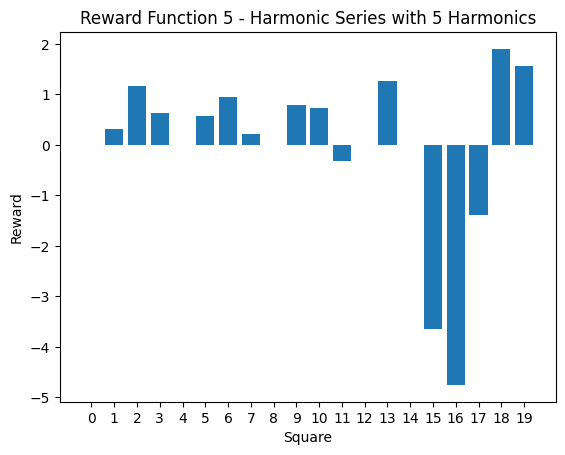

In [32]:
# Creation of the vector of reward functions

def make_harmonic_reward_function(num_harmonics):

    def reward_function(meeting_square, world_dimension):
        x = (meeting_square / world_dimension) * 2 * np.pi
        reward = 0
        for n in range(1, num_harmonics + 1):
            phi = (n -1)* 2 * np.pi / num_harmonics  # Phase shift for each harmonic
            reward += np.sin(n * x + phi)

        return reward, -reward

    return reward_function

# Plot the armonics

for n in range(1, NUMBER_OF_HARMONICS + 1):
    x = np.linspace(0, NUMBER_OF_SQUARES - 1, 1000)
    x = (x / NUMBER_OF_SQUARES) * 2 * np.pi  # Normalize to [0, 2π]
    y = np.sin(n * x + n - 1)  # Harmonic function
    plt.plot(x, y, label=f'Harmonic {n}', alpha=0.7)
plt.title('Harmonic Functions')
plt.xlabel('Square')
plt.ylabel('Value')
plt.legend()
plt.show()

# Create a list of reward functions with increasing complexity
reward_functions = [make_harmonic_reward_function(n) for n in range(1, NUMBER_OF_HARMONICS + 1)]

x = np.arange(NUMBER_OF_SQUARES)
for i, reward_function in enumerate(reward_functions):
    # Get the rewards of Alice for each square
    rewards = [reward_function(square, NUMBER_OF_SQUARES)[0] for square in x]
    plt.bar(x, rewards)
    plt.title(f'Reward Function {i + 1} - Harmonic Series with {i + 1} Harmonics')
    plt.xlabel('Square')
    plt.ylabel('Reward')
    plt.xticks(x)
    plt.show()




Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Number of compenetrations prevented: 2047
Percentage of games affected by compenetrations: 20.47%


Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Number of compenetrations prevented: 1975
Percentage of games affected by compenetrations: 19.75%


Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Number of compenetrations prevented: 2029
Percentage of games affected by compenetrations: 20.29%


Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Number of compenetrations prevented: 2051
Percentage of games affected by compenetrations: 20.51%


Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Number of compenetrations prevented: 1944
Percentage of games affected by compenetrations: 19.44%


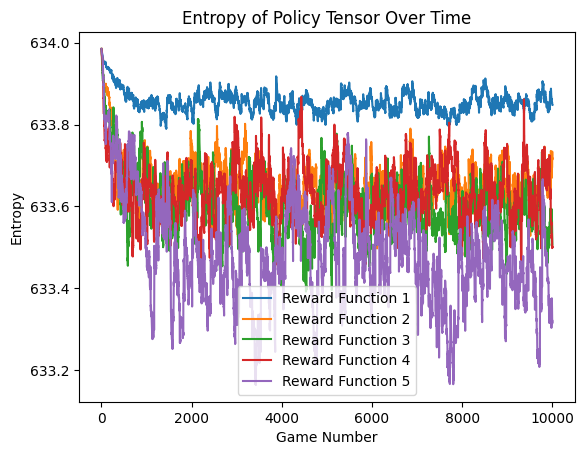

In [33]:
def calculate_entropy_of_policy_tensor(policy_tensor):
  entropy = 0
  for i in range(policy_tensor.shape[0]):
    for j in range(policy_tensor.shape[1]):
      for k in range(policy_tensor.shape[2]):
        entropy -= policy_tensor[i, j, k] * np.log2(policy_tensor[i, j, k])

  return entropy

def playgames(walker_1, walker_2, world_dimension, reward_function, number_of_games=NUMBER_OF_GAMES):

    entropy_list = []
    meeting_squares = []
    number_of_compenetrations_prevented = 0

    for _ in tqdm(range(number_of_games), desc='Playing'):

        policy_tensor = walker_1.get_policy_tensor()
        entropy = calculate_entropy_of_policy_tensor(policy_tensor)
        entropy_list.append(entropy)

        _, _, _, meeting_square, compenetration = play_one_game(
            walker_1, walker_2, world_dimension, reward_function
        )

        if compenetration:
            number_of_compenetrations_prevented += 1

        meeting_squares.append(meeting_square)

    return entropy_list, meeting_squares, number_of_compenetrations_prevented

# Train the walkers with different reward functions

entropy_results = []
trained_walkers = []

for reward_function in reward_functions:

    # Initialize the walkers
    walker_alice = Walker(
        name='Alice',
        start_position=START_POS_ALICE,
        world_dimension=NUMBER_OF_SQUARES,
        use_brain=True,
        learn=True
    )
    walker_bob = Walker(
        name='Bob',
        start_position=START_POS_BOB,
        world_dimension=NUMBER_OF_SQUARES,
        use_brain=False,
        learn=False
    )

    entropy_list, _, number_of_comp_prev = playgames(
        walker_alice, walker_bob, NUMBER_OF_SQUARES, reward_function
        )
    
    entropy_results.append(entropy_list)
    trained_walkers.append({
        'walker_alice': walker_alice,
        'walker_bob': walker_bob
    })

    print(f'Number of compenetrations prevented: {number_of_comp_prev}')
    print(f'Percentage of games affected by compenetrations: {number_of_comp_prev / NUMBER_OF_GAMES * 100:.2f}%')

# Plot the entropy results
for i, entropy_list in enumerate(entropy_results):
    plt.plot(entropy_list, label=f'Reward Function {i + 1}')
plt.title('Entropy of Policy Tensor Over Time')
plt.xlabel('Game Number')
plt.ylabel('Entropy')
plt.legend()
plt.show()

Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

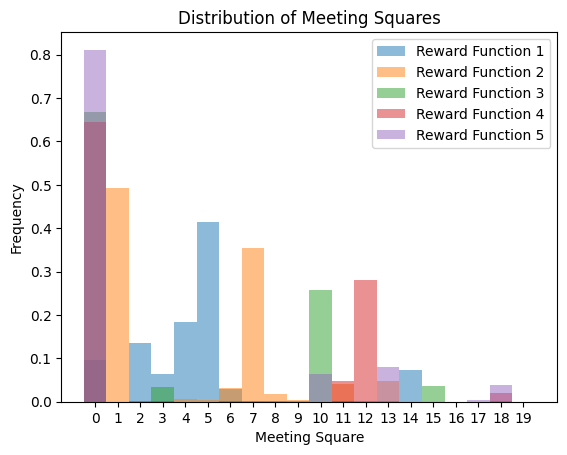

In [34]:
# Get the meeting squares for the trained walkers
meeting_results = []
for couple in trained_walkers:
    walker_alice = couple['walker_alice']
    walker_alice.learn = False # Disable learning for the final evaluation
    walker_alice.softmax_temperature = 0.01  # Set a low temperature for exploitation
    walker_bob = couple['walker_bob']
    _, meeting_squares, _ = playgames(
        walker_alice, walker_bob, NUMBER_OF_SQUARES, reward_function
    )
    meeting_results.append(meeting_squares)

# Plot the meeting squares
for i, meeting_squares in enumerate(meeting_results):
    plt.hist(meeting_squares, bins=np.arange(NUMBER_OF_SQUARES + 1) - 0.5, density=True, alpha=0.5, label=f'Reward Function {i + 1}')
plt.title('Distribution of Meeting Squares')
plt.xlabel('Meeting Square')
plt.ylabel('Frequency')
plt.xticks(np.arange(NUMBER_OF_SQUARES))
plt.legend()
plt.show()